In [32]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/lion18s/SA01.txt")

In [33]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = 20  # Anzahl Anfragen pro Episode; entspricht Instanz "WC4" (K=12, |N|=1000, C=10, T_d=10) aus Tabelle 1 des Papers, Z*=1.53
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length
pool_size = DRAUSP_data.pool_size
print(f"Number of slots (K): {K}")
print(f"Number of requests per episode (T_d): {T_d}")
print(f"Pool size (|N|): {pool_size}")
print(f"Capacity vector (C_k): {C_k}")
print(f"Instance: {instance}")

Number of slots (K): 4
Number of requests per episode (T_d): 20
Pool size (|N|): 50
Capacity vector (C_k): [10, 10, 10, 10]
Instance: [[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79,

In [34]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)
env.reset(show_instance = True)

Geladene Instanz:
  Anfrage 1: [70, 1, 3, 0, 0]
  Anfrage 2: [63, 3, 2, 0, 0]
  Anfrage 3: [74, 1, 1, 0, 0]
  Anfrage 4: [69, 2, 1, 0, 0]
  Anfrage 5: [81, 1, 2, 0, 0]
  Anfrage 6: [67, 1, 1, 0, 0]
  Anfrage 7: [77, 1, 1, 0, 0]
  Anfrage 8: [92, 1, 1, 0, 0]
  Anfrage 9: [69, 1, 3, 0, 0]
  Anfrage 10: [60, 1, 1, 0, 0]
  Anfrage 11: [70, 1, 3, 0, 0]
  Anfrage 12: [84, 1, 1, 0, 0]
  Anfrage 13: [80, 1, 1, 0, 0]
  Anfrage 14: [92, 1, 1, 0, 0]
  Anfrage 15: [61, 2, 1, 0, 0]
  Anfrage 16: [39, 1, 3, 0, 0]
  Anfrage 17: [47, 3, 1, 0, 0]
  Anfrage 18: [54, 1, 1, 0, 0]
  Anfrage 19: [60, 1, 1, 0, 0]
  Anfrage 20: [84, 1, 1, 0, 0]


(array([ 1., 10., 10., 10., 10., 70.,  1.,  3.,  0.,  0.], dtype=float32),
 {'valid_actions': [0, 1, 2, 3]})

## Hier kann getestet werden ob alle Transitions korrekt funktionieren
Mit render bekommt man eine Übersicht was gerade los ist

In [35]:
obs, info = env.reset()
print(obs)
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
print(terminated)
env.render()

[ 1. 10. 10. 10. 10. 18.  2.  1.  0.  0.]
t=2    Caps=[8, 9, 10, 10]  r=20.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=3    Caps=[7, 6, 10, 10]  r=21.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=4    Caps=[5, 5, 10, 10]  r=50.00  q=[3, 2, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=5    Caps=[2, 3, 10, 10]  r=92.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=6    Caps=[1, 2, 10, 10]  r=39.00  q=[1, 2, 0, 0]  Valid Actions: [0, 1, 2, 3]
False
t=7    Caps=[0, 0, 10, 10]  r=54.00  q=[1, 1, 0, 0]  Valid Actions: [0, 3]


In [36]:
from training.dqn_agent import DQNAgent
from models.standard_dqn import DQNNetwork
agent = DQNAgent(env, QnetworkClass=DQNNetwork, monotonicity_penalty=False, reject_bias = 0.75, gamma = 0.98, epsilon_decay_steps=10000)

In [37]:
reward_history, monotonicity_violations, depth_history = agent.train(num_episodes=1500)

  Systematic monotonicity (Episode 1): C_k: 71.2%, t: 31.6%, r: 75.0%, q: 45.0%, mixed: 65.3%
Episode   50/1500  Reward:   300.00  Avg(50):   291.40  Tiefe:   20  Avg-Tiefe(50):   20.0  ε: 0.914
  Systematic monotonicity (Episode 51): C_k: 100.0%, t: 22.4%, r: 100.0%, q: 0.0%, mixed: 100.0%
Episode  100/1500  Reward:   366.00  Avg(50):   368.90  Tiefe:   20  Avg-Tiefe(50):   19.5  ε: 0.839
  Systematic monotonicity (Episode 101): C_k: 100.0%, t: 5.3%, r: 98.8%, q: 0.0%, mixed: 100.0%
Episode  150/1500  Reward:   335.00  Avg(50):   403.86  Tiefe:   20  Avg-Tiefe(50):   19.8  ε: 0.769
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 22.4%, r: 92.5%, q: 0.0%, mixed: 100.0%
Episode  200/1500  Reward:   432.00  Avg(50):   414.50  Tiefe:   20  Avg-Tiefe(50):   19.1  ε: 0.708
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 35.5%, r: 88.7%, q: 0.0%, mixed: 100.0%
Episode  250/1500  Reward:   437.00  Avg(50):   434.40  Tiefe:   20  Avg-Tiefe(50):   18.8  ε: 0.654
  Systematic m

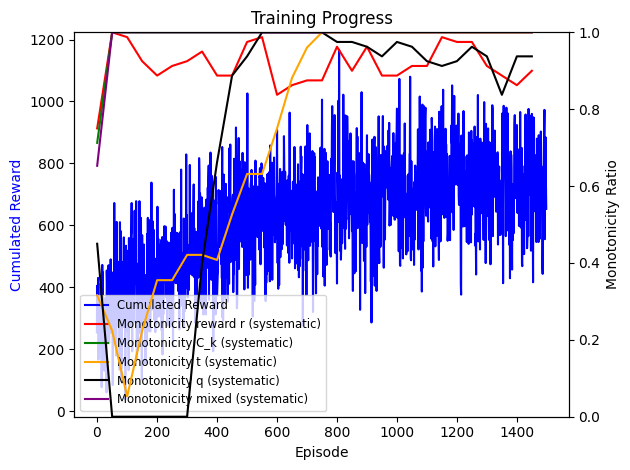

In [38]:
from training.plotting import plot_training_progress, plot_depth_epsilon

plot_training_progress(reward_history, monotonicity_violations)

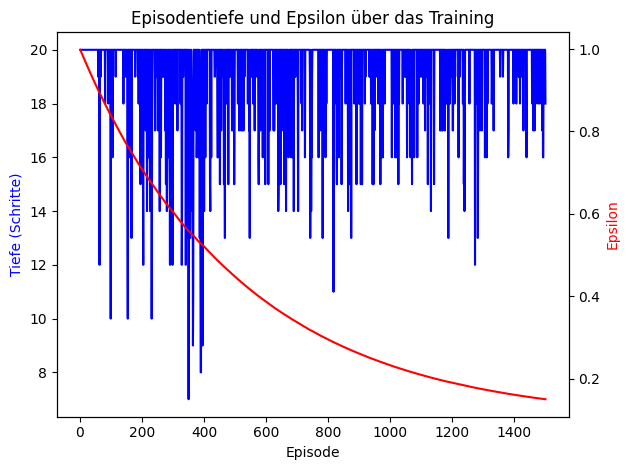

In [39]:
plot_depth_epsilon(depth_history)

## Beispiel-Durchlauf des trainierten Agenten

In [40]:
agent.epsilon = 0.0  # rein exploitativ, keine Exploration

obs, info = env.reset(show_instance = True)
done = False
total_reward = 0.0

while not done:
    action = agent.select_action(obs)
    print(f"Aktion gewählt: {action}")
    obs, reward, terminated, truncated, info = env.step(action)
    env.render()
    total_reward += reward
    done = terminated or truncated

print(f"\nGesamtreward (greedy Durchlauf): {total_reward:.2f}")

Geladene Instanz:
  Anfrage 1: [22, 1, 1, 0, 0]
  Anfrage 2: [47, 3, 1, 0, 0]
  Anfrage 3: [54, 1, 1, 0, 0]
  Anfrage 4: [79, 1, 2, 0, 0]
  Anfrage 5: [9, 1, 2, 0, 0]
  Anfrage 6: [92, 1, 1, 0, 0]
  Anfrage 7: [74, 1, 1, 0, 0]
  Anfrage 8: [20, 1, 1, 0, 0]
  Anfrage 9: [43, 1, 2, 0, 0]
  Anfrage 10: [43, 1, 2, 0, 0]
  Anfrage 11: [88, 2, 1, 0, 0]
  Anfrage 12: [34, 2, 1, 0, 0]
  Anfrage 13: [81, 1, 2, 0, 0]
  Anfrage 14: [18, 2, 1, 0, 0]
  Anfrage 15: [58, 1, 2, 0, 0]
  Anfrage 16: [67, 1, 1, 0, 0]
  Anfrage 17: [54, 3, 2, 0, 0]
  Anfrage 18: [47, 3, 1, 0, 0]
  Anfrage 19: [79, 1, 2, 0, 0]
  Anfrage 20: [39, 1, 3, 0, 0]
Aktion gewählt: 3
t=2    Caps=[10, 10, 9, 9]  r=47.00  q=[3, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 3
t=3    Caps=[10, 10, 6, 8]  r=54.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 3
t=4    Caps=[10, 10, 5, 7]  r=79.00  q=[1, 2, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 3
t=5    Caps=[10, 10, 4, 5]  r=9.00  q=[1, 2, 0, 0]  Valid